In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from kelly_utils import kelly, drawdown

In [ ]:
# USER SETTINGS

periods = 252
n_years = 30

burn_in = periods * 10

max_leverage = 10.0
min_leverage = 0.0

f = 0.5

Rebalancing = 252  # Times per year

scale_long = "none"  # options: "none", "same_avg_vol", "vol_targeting"

sharpe = "constant"  # options: "constant", "variable"

annual_ret = 0.05

expected_return = "unknown"    # "known" or "unknown"
return_vol_relation = True
expected_vol    = "known"      # "known" or "unknown"

SR = 0.40  # Expected annualized sharpe ratio.

m = 0.00  # degree of momentum

tc = 0.001

use_momentum = False
use_TC = False
return_paths = True

# Parameters for volatility simulations

p_LL = 0.999
p_HH = 0.99
vol_low_annual = 0.15   
vol_high_annual = 0.20
rho = 0.95
std_lns = 0.05
jumps_per_year = 0.5
jump_prob = 1 - np.exp(-jumps_per_year*(1/periods))
jump_size = 0.30

c = SR / np.sqrt(periods)

In [ ]:
results = kelly(
    n_years,
    periods,
    burn_in,
    p_LL,
    p_HH,
    vol_low_annual,
    vol_high_annual,
    rho,
    std_lns,
    jump_prob,
    jump_size,
    c,
    m,
    annual_ret,
    sharpe,
    f,
    min_leverage,
    max_leverage,
    Rebalancing,
    scale_long,
    use_momentum,
    use_TC,
    return_paths, 
    tc, 
    expected_return, 
    return_vol_relation, 
    expected_vol
)

In [10]:
table = pd.DataFrame({
    "Buy-and-Hold": {
        "Sharpe ratio": results["sharpe_long"],
        "Final Wealth": results["final_wealth_long"],
        "Max Drawdown": results["max_dd_long"],
    },
    "Kelly": {
        "Sharpe ratio": results["sharpe_kelly"],
        "Final Wealth": results["final_wealth_kelly"],
        "Max Drawdown": results["max_dd_kelly"],
    },
    "Vol Targeting": {
        "Sharpe ratio": results["sharpe_volTarget"],
        "Final Wealth": results["final_wealth_volTarget"],
        "Max Drawdown": results["max_dd_volTarget"],
    }
})

# Round for display
print(table.round(4))

              Buy-and-Hold    Kelly  Vol Targeting
Sharpe ratio        0.6081   0.7063         0.5808
Final Wealth       13.5916  82.0253        11.2330
Max Drawdown       -0.4125  -0.5506        -0.4026


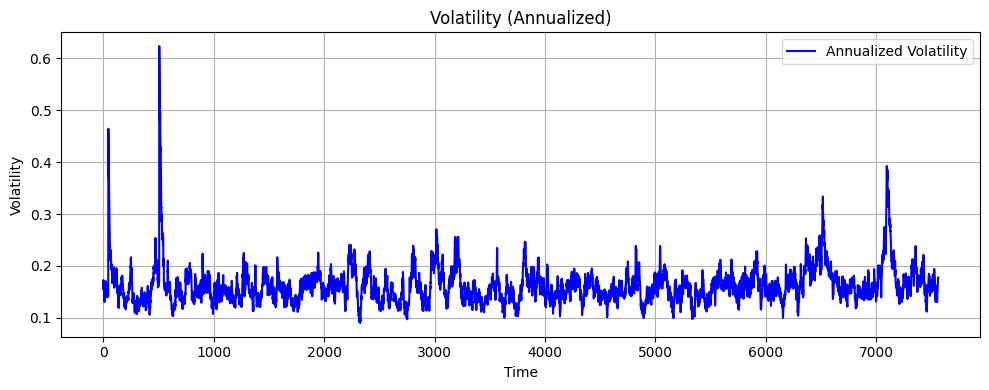

In [11]:
# Plot volatility path (annualized)
plt.figure(figsize=(10, 4))
plt.plot(results["volatility_path"], label="Annualized Volatility", color="blue")
plt.title("Volatility (Annualized)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

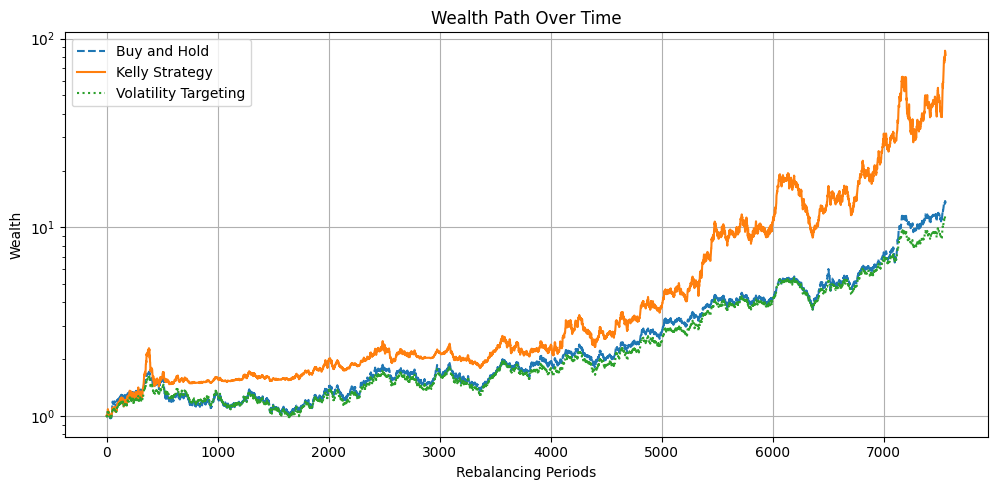

In [12]:
# Plot wealth paths
plt.figure(figsize=(10, 5))
plt.plot(results["wealth_paths"]["buy_and_hold"], label="Buy and Hold", linestyle="--")
plt.plot(results["wealth_paths"]["kelly"], label="Kelly Strategy", linestyle="-")
plt.plot(results["wealth_paths"]["vol_target"], label="Volatility Targeting", linestyle=":")
plt.title("Wealth Path Over Time")
plt.xlabel("Rebalancing Periods")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale("log")
plt.show()


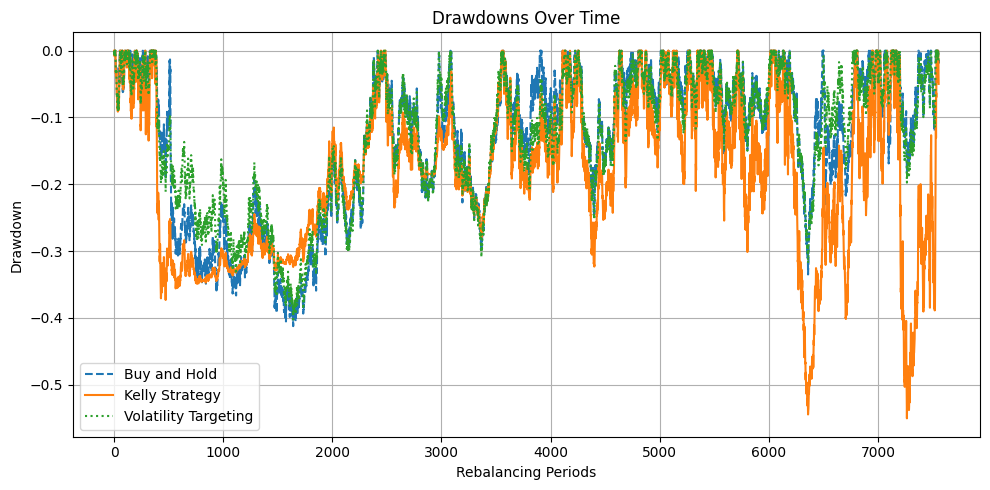

In [13]:
# Compute drawdowns
dd_long = drawdown(results["wealth_paths"]["buy_and_hold"])
dd_kelly = drawdown(results["wealth_paths"]["kelly"])
dd_volT = drawdown(results["wealth_paths"]["vol_target"])

# Plot drawdowns
plt.figure(figsize=(10, 5))
plt.plot(dd_long, label="Buy and Hold", linestyle="--")
plt.plot(dd_kelly, label="Kelly Strategy", linestyle="-")
plt.plot(dd_volT, label="Volatility Targeting", linestyle=":")
plt.title("Drawdowns Over Time")
plt.xlabel("Rebalancing Periods")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
kelly_w = results["kelly_weights"]
volT_w = results["vol_target_weights"]

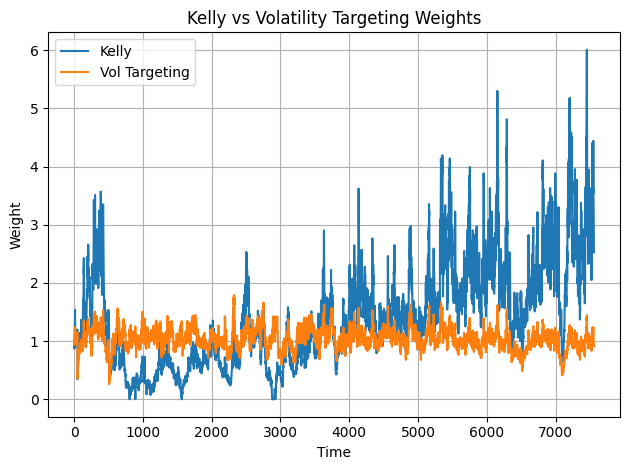

In [15]:
plt.plot(kelly_w, label="Kelly")
plt.plot(volT_w, label="Vol Targeting")
plt.title("Kelly vs Volatility Targeting Weights")
plt.xlabel("Time")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
n_sims = 100

records = []
for sim in range(n_sims):
    res = kelly(n_years, periods, burn_in, 
        p_LL, p_HH, vol_low_annual, vol_high_annual, rho, std_lns, jump_prob, jump_size,
        c, m, annual_ret, sharpe, f, min_leverage, max_leverage, Rebalancing,
        scale_long, use_momentum, use_TC, return_paths, tc, expected_return, expected_vol
    )

    # collect every metric from your table
    records.append({
        'sim': sim,
        # Buy-and-Hold
        'bh_sharpe':        res['sharpe_long'],
        'bh_final_wealth':  res['final_wealth_long'],
        'bh_max_dd':        res['max_dd_long'],
        # Kelly
        'kelly_sharpe':        res['sharpe_kelly'],
        'kelly_final_wealth':  res['final_wealth_kelly'],
        'kelly_max_dd':        res['max_dd_kelly'],
        # Vol Targeting
        'vol_sharpe':        res['sharpe_volTarget'],
        'vol_final_wealth':  res['final_wealth_volTarget'],
        'vol_max_dd':        res['max_dd_volTarget'],
    })

# build DataFrame of shape (n_sims x 9 metrics)
df_mc = pd.DataFrame.from_records(records).set_index('sim')


# quick summary
print(df_mc.describe())

        bh_sharpe  bh_final_wealth   bh_max_dd  kelly_sharpe  \
count  100.000000       100.000000  100.000000    100.000000   
mean     0.494863        10.500779   -0.433618      0.569984   
std      0.174753         9.606024    0.104832      0.152204   
min     -0.043139         0.559464   -0.698057      0.074234   
25%      0.385514         4.395577   -0.499539      0.473373   
50%      0.487507         7.206553   -0.428791      0.567596   
75%      0.621098        13.743295   -0.350415      0.679303   
max      0.932842        55.151830   -0.267815      0.949812   

       kelly_final_wealth  kelly_max_dd  vol_sharpe  vol_final_wealth  \
count          100.000000    100.000000  100.000000        100.000000   
mean           570.445931     -0.625959    0.499424         10.165907   
std           2542.034302      0.125352    0.171684          9.273150   
min              1.076115     -0.852465   -0.021726          0.628316   
25%             12.921846     -0.701341    0.395787       

In [17]:
"""          
 kelly_final_wealth  kelly_max_dd   
count         1000.000000          1000.000000  
mean           173.457262          -0.633378    
std            476.729634           0.109541     
min              0.429823          -0.947910     
25%             17.177409          -0.712420     
50%             46.095249          -0.625424     
75%            134.451064          -0.553164     
max           7699.372659          -0.367833     

       kelly_final_wealth          kelly_max_dd   
count         1000.000000          1000.000000  
mean           300.767620          -0.508438  
std           1576.345515           0.147057  
min              0.279180          -0.923381  
25%             10.957120          -0.610634  
50%             35.086767          -0.499448  
75%            145.526673          -0.402510  
max          33799.114586          -0.153998  

"""

'          \n kelly_final_wealth  kelly_max_dd   \ncount         1000.000000          1000.000000  \nmean           173.457262          -0.633378    \nstd            476.729634           0.109541     \nmin              0.429823          -0.947910     \n25%             17.177409          -0.712420     \n50%             46.095249          -0.625424     \n75%            134.451064          -0.553164     \nmax           7699.372659          -0.367833     \n\n       kelly_final_wealth          kelly_max_dd   \ncount         1000.000000          1000.000000  \nmean           300.767620          -0.508438  \nstd           1576.345515           0.147057  \nmin              0.279180          -0.923381  \n25%             10.957120          -0.610634  \n50%             35.086767          -0.499448  \n75%            145.526673          -0.402510  \nmax          33799.114586          -0.153998  \n\n'

In [18]:
""""
n_sims  = 1000
summary = []

for f_test in [0.5, 0.75, 1.0, 1.25, 1.5]:
    records = []
    for sim in range(n_sims):
        res = kelly(
            n_years, periods, burn_in,
            p_LL, p_HH, vol_low_annual, vol_high_annual, rho, std_lns,
            jump_prob, jump_size, c, m, annual_ret, sharpe, f_test,
            min_leverage, max_leverage, Rebalancing, scale_long,
            use_momentum, use_TC, True,  # return_paths=True
            tc
        )

        # compute average drawdown from the wealth path
        def avg_dd(wealth):
            hwm = np.maximum.accumulate(wealth)
            dd  = 1 - wealth / hwm
            return dd.mean()

        # extract everything
        records.append({
            # final wealth
            'bh_fw':    res['final_wealth_long'],
            'kelly_fw': res['final_wealth_kelly'],
            'vol_fw':   res['final_wealth_volTarget'],
            # max drawdown
            'bh_max_dd':    res['max_dd_long'],
            'kelly_max_dd': res['max_dd_kelly'],
            'vol_max_dd':   res['max_dd_volTarget'],
            # mean drawdown
            'bh_avg_dd':    avg_dd(res['wealth_paths']['buy_and_hold']),
            'kelly_avg_dd': avg_dd(res['wealth_paths']['kelly']),
            'vol_avg_dd':   avg_dd(res['wealth_paths']['vol_target']),
            # weights & vol path means
            'kelly_w_m':       res['kelly_weights'].mean(),
            'VT_w_m':       res['vol_target_weights'].mean(),
            'vol_path_m': res['volatility_path'].mean(),
        })

    df_mc = pd.DataFrame.from_records(records)

    # compute the mean of each column across sims
    m = df_mc.mean()

    # collect into summary
    summary.append({'f_test': f_test, **m.to_dict()})

# build summary DataFrame
summary_df = pd.DataFrame(summary).set_index('f_test')

# transpose to get: rows=metrics, cols=f_test
final_table = summary_df

print(final_table)
""""

SyntaxError: unterminated string literal (detected at line 58) (1039994965.py, line 58)